# Coursework 1
**Replace CID in the file name with your CID**

# Outline


- [Task 1](#task-1): Linear regression and feature selection <a name="index-task-1"></a>
  - [(1.1)](#task-11) <a name="index-task-11"></a>
  - [(1.2)](#task-12) <a name="index-task-12"></a>
  - [(1.3)](#task-13) <a name="index-task-13"></a>
  - [(1.4)](#task-14) <a name="index-task-14"></a>
- [Task 2](#task-2): Non-linear regression with Kernel Ridge Regression <a name="index-task-2"></a>
  - [(2.1)](#task-21) <a name="index-task-21"></a>
  - [(2.2)](#task-22)  <a name="index-task-22"></a>
- [Task 3](#task-3): Classification with the Multi-Layer Perceptron <a name="index-task-3"></a>
  - [(3.1)](#task-31) <a name="index-task-31"></a>
  - [(3.2)](#task-32)  <a name="index-task-32"></a>



---



<a name="task-1"></a>

# Task 1: Linear regression and feature selection [(index)](#index-task-1)

In [1]:
# import useful packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# set global config for matplotlib to make plots readable
SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

rng = np.random.default_rng(0)

In [2]:
# load data
data_train = pd.read_csv("asteroid_observations_train.csv")
data_test = pd.read_csv("asteroid_observations_test.csv")

# show the shape of the data
print("train data shape: ", data_train.shape)
print("test data shape: ", data_test.shape)

data_train.head()

train data shape:  (638, 9)
test data shape:  (160, 9)


,Absolute magnitude,Albedo,Number of observations,Observation arc length,Orbital eccentricity,Orbital inclination,Orbital period,Asteroid diameter,Asteroid class
0,18.1,0.041,15,2.0,0.201590,11.975800,3.912298,1.573,MBA
1,12.5,0.139,349,7208.0,0.032746,8.793883,11.942668,12.355,TJN
2,14.1,0.062,705,25309.0,0.179314,27.433960,5.749452,8.862,OMB
3,16.9,0.097,91,3805.0,0.066114,13.813845,4.592982,2.139,MBA
4,11.5,0.062,1300,9606.0,0.008824,5.595907,12.006096,30.763,TJN


In [3]:
data_test.head()

,Absolute magnitude,Albedo,Number of observations,Observation arc length,Orbital eccentricity,Orbital inclination,Orbital period,Asteroid diameter,Asteroid class
0,16.00,0.061,371,9126.0,0.144324,12.018294,4.266851,3.888,MBA
1,14.20,0.079,528,10262.0,0.049446,20.973974,5.802442,7.860,OMB
2,10.71,0.045,2464,35751.0,0.185255,5.629857,7.950795,45.117,OMB
3,13.00,0.054,1157,9248.0,0.134931,4.428840,7.884727,15.014,OMB
4,15.20,0.075,390,7176.0,0.071674,16.578118,5.460715,5.330,MBA


In [4]:
# features
features = data_test.columns[:-2]
features

Index(['Absolute magnitude', 'Albedo', 'Number of observations',
       'Observation arc length', 'Orbital eccentricity', 'Orbital inclination',
       'Orbital period'],
      dtype='str')

<a name="task-11"></a>

## (1.1) [(index)](#index-task-11)

In [5]:
# create data matrix
X_train = np.asarray(data_train.iloc[:, :-2])
X_test = np.asarray(data_test.iloc[:, :-2])

# create label vector
y_train = np.asarray(data_train.loc[:, 'Asteroid diameter'])
y_test = np.asarray(data_test.loc[:, 'Asteroid diameter'])

In [6]:
# standardise data to expection = 0 and standard deviation = 1
def standardise(X, X_train_=None):
    """
    Standardise features.

    Parameters:
        X (np.array): Feature matrix.
        X_train_ (np.array): An optional feature matrix to compute the statistics
            from before applying it to X. If None, just use X to compute the statistics.

    Returns:
        X_std (np.array): Standardised feature matrix
    """
    if X_train_ is None:
        X_train_ = X

    mu = np.mean(X_train_, axis=0, keepdims=True)
    sigma = np.std(X_train_, axis=0, keepdims=True)
    X_std = (X - mu) / sigma

    return X_std

X_train_std = standardise(X=X_train)
X_test_std = standardise(X=X_test, X_train_=X_train)

The solution of the the (ordinary) least squares is
$$
\boldsymbol{\hat{\beta}^{LS}} = (\boldsymbol X^T\boldsymbol X)^{-1}\boldsymbol X^T\boldsymbol y \,,
$$

In the method fit_ols(), we add an interception feature on the first column of the data matrix $X$, so it returns
$$
\boldsymbol{\hat{\beta}^{LS}}  = (\hat{\beta}_{0}^{LS}, \hat{\beta}_{1}^{LS}, \dots, \hat{\beta}_{p}^{LS})^T
$$


In [7]:
# fit the ordinary least squares
def fit_ols(X, y):
    """
    return the beta_ls of OLS problem.
    """
    # check the shape
    N, p = X.shape
    y = np.asarray(y).reshape(-1, 1)
    assert y.shape[0] == N

    # add intercept
    X_aug = np.hstack([np.ones((N, 1)), X])

    # apply formula
    beta_ls = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)
    assert beta_ls.shape[0] == (p + 1)
    
    return beta_ls.flatten()

For Garrote, $f_{\boldsymbol{\beta}^G,\hat{\beta}_0^{LS}}(x) = x^{T}\boldsymbol{\beta}^G + \hat{\beta}_0^{LS}$ where $\beta^{G}_{j} = g_j\hat{\beta}^{LS}_{j}$

The optimisation problem is:
$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}\sum_{i=1}^{N^{\mathrm{train}}}
\left(y^{(i)}-f_{\beta^G,\hat{\beta}_0^{LS}}\!\left(x^{(i)}\right)\right)^2
\right].
\\
\text{such that }
\lVert_{} \boldsymbol{g}\rVert_{1}=\sum_{j=1}^{p}\lvert g_{j}\rvert < s
\qquad \text{for some } s\in\mathbb{R}_{\ge 0}.
$$
which is equivalent to
$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}\sum_{i=1}^{N^{\mathrm{train}}}
\left(y^{(i)}- {x^{(i)}}^{T} \boldsymbol{\beta}^G - \hat{\beta}_0^{LS}\right)^2 + \lambda \lVert_{} \boldsymbol{g}\rVert_{1}
\right].
$$


since we can rewrite $\boldsymbol{\beta}^{G} = \text{diag}(\hat{\beta}^{LS}_1, \hat{\beta}^{LS}_2, \dots, \hat{\beta}^{LS}_p)g$, let $D = \text{diag}(\hat{\beta}^{LS}_1, \hat{\beta}^{LS}_2, \dots, \hat{\beta}^{LS}_p)$, so the optimisation problem is 

$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}
\|\boldsymbol y - {X} \boldsymbol{\beta}^G - \hat{\beta}_0^{LS} \mathbf{1} \|_2^2 + \lambda \lVert_{} \boldsymbol{g}\rVert_{1}
\right].
$$

$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}
\|\boldsymbol y - {X} {D} \boldsymbol g - \hat{\beta}_0^{LS} \mathbf{1} \|_2^2 + \lambda \lVert_{} \boldsymbol{g}\rVert_{1}
\right].
$$

Replace $\lVert_{} \boldsymbol{g}\rVert_{1}$ by Huber loss $\sum_{i=1}^{p} L_c(g_i)$

$$
L_c (g_i) =
\begin{cases}
 \frac{1}{2}{g^2_i}                   & \text{for } |g_i| \le c, \\
 c (|g_i| - \frac{1}{2}c), & \text{otherwise,}
\end{cases}
$$

$$
\frac{dL_c (g_i)}{d g_i} =
  \begin{cases}
 g_i                   & \text{for } |g_i| \le c, \\
 c\, \text{sign}(g_i) , & \text{otherwise,}
\end{cases}
$$

So the final Loss function is

$$
L(\boldsymbol g) = \frac{1}{N^{\mathrm{train}}}
\|\boldsymbol y - {X} {D} \boldsymbol g - \hat{\beta}_0^{LS} \mathbf{1} \|_2^2 + \lambda \sum_{i=1}^{p} L_c(g_i). \\
= \frac{1}{N^{\mathrm{train}}}
(\boldsymbol{y}^T \boldsymbol{y} - \boldsymbol{g}^T (\boldsymbol{X}D)^T \boldsymbol{y} - \boldsymbol{y}^T (\boldsymbol{X}D) \boldsymbol{g}
+ \boldsymbol{g}^T(\boldsymbol{X}D)^T(\boldsymbol{X}D)\boldsymbol{g} \\
- \hat{\beta_0^{LS}} \mathbf{1}^T \boldsymbol y - \hat{\beta_0^{LS}} \boldsymbol{y}^T \mathbf{1} + \hat{\beta_0^{LS}}^2 \mathbf{1}^T\mathbf{1} \\
+ \hat{\beta_0^{LS}} (\mathbf{1}^T \boldsymbol X D) \boldsymbol{g} + \hat{\beta_0^{LS}} \boldsymbol{g}^T (\boldsymbol X D)^T \mathbf{1}) \\
+ \lambda \sum_{i=1}^{p} L_c(g_i)
$$

So the gradient of the loss funtion is
$$
\nabla_{\boldsymbol g}{L} = \frac{2}{N^{\mathrm{train}}} (\boldsymbol X D)^T (\boldsymbol X Dg + \hat{\beta}_0^{LS} \mathbf{1} - \boldsymbol y) + \lambda \nabla_{\boldsymbol g}{L_c}
$$

In [8]:
# huber loss
def huber(g, c_huber=1e-4):
    return np.where(np.abs(g) <= c_huber, (g ** 2) / 2., c_huber * (np.abs(g) - c_huber / 2))

# gradient of huber loss
def grad_huber(g, c_huber=1e-4):
    return  np.where(np.abs(g) <= c_huber, g, c_huber * np.sign(g))

# loss function
def compute_loss(g, X, y, beta, lambd, c_huber=1e-4):
    N_train, p = X.shape
    assert y.shape[0] == N_train

    # extract the interception and D matrix and other useful vector
    beta_0 = beta[0]
    beta_1_p = beta[1:]
    assert beta_1_p.shape[0] == p

    # X @ D
    XD = X * beta_1_p

    huber_loss = huber(g, c_huber)
    loss = (1 / N_train) * np.sum((y - XD @ g - beta_0) ** 2) + lambd * np.sum(huber_loss)

    return loss

# gradient of loss function
def grad_loss(g, X, y, beta, lambd, c_huber=1e-4):
    """
    g: (p) vector: parametre of Garrote
    X: (N, p) matrix: data
    y: (N) vector: label
    beta: (p + 1) vector: the learnt parametre of OLS
    lambd: float: regulation parametre
    c_huber: float: smooth parametre
    """
    N_train, p = X.shape
    assert y.shape[0] == N_train

    # extract the interception and D matrix and other useful vector
    beta_0 = beta[0]
    beta_1_p = beta[1:]
    assert beta_1_p.shape[0] == p

    # compute the gradient of Huber loss part
    grad_c = grad_huber(g, c_huber=c_huber)

    # compute the gradient of the loss funtion
    XD = X * beta_1_p
    grad = (2 / N_train) * XD.T @ (XD @ g + beta_0 - y) + lambd * grad_c

    return grad

Then we implement gradient descent since there is no analytic for this problem.
$$
\boldsymbol{g}_{t + 1} = \boldsymbol{g}_{t} - \eta_t \nabla_{\boldsymbol g} L(\boldsymbol{g}_{t})

In [9]:
def gradient_descent(X, y, beta, lambd, n_iters=10000, step_size=1e-7, c_huber=1e-4, print_outcome=False):
    N, p = X.shape
    assert y.shape[0] == N

    # initialize the parametre
    g = np.zeros(p)
    nth = 0
    loss_history = []  # Track loss values
    epochs_list = []  # Track epoch numbers

    for epoch in range(1, n_iters + 1):
        # update g
        grad = grad_loss(g, X, y, beta, lambd, c_huber)
        g = g - step_size * grad

        # Check for convergence at 2^nth epoch or last epoch
        if epoch == 2**nth or epoch == n_iters:
            # Compute the current loss
            loss = compute_loss(g, X, y, beta, lambd, c_huber)
            if print_outcome:
                print(f'Epoch: {epoch}, Loss: {loss:.6f}')

            # Update tracking variables
            epochs_list.append(epoch)
            loss_history.append(loss)
            nth += 1

    return g, loss_history, epochs_list

The train process is :
1. fit OLS and get $\hat{\boldsymbol\beta}^{LS}$
2. gradient descent on Garrote problem and get $\boldsymbol g$

In [10]:
def train_garrote(X_train, y_train, lambd, n_iters=10000, step_size=1e-7, c_huber=1e-4, print_outcome=False):
    # check dimention
    N, p = X_train.shape
    assert y_train.shape[0] == N

    # first get the ols coefficient
    beta_LS = fit_ols(X_train, y_train)

    # use gradient descent to get the optimal g
    g, loss_history, epochs_list = gradient_descent(X_train, y_train, beta_LS, lambd, n_iters, step_size, c_huber, print_outcome)

    # get the Garrote coefficient
    beta_G = g * beta_LS[1:]

    return beta_G, beta_LS, g, loss_history, epochs_list

In [11]:
# example
beta_G, beta, g, loss_history, epochs_list = train_garrote(X_train=X_train_std, y_train=y_train, lambd=1e-2, step_size=1e-7, print_outcome=True)

Epoch: 1, Loss: 178.353522
Epoch: 2, Loss: 178.349138
Epoch: 4, Loss: 178.340369
Epoch: 8, Loss: 178.322835
Epoch: 16, Loss: 178.287774
Epoch: 32, Loss: 178.217680
Epoch: 64, Loss: 178.077611
Epoch: 128, Loss: 177.797943
Epoch: 256, Loss: 177.240481
Epoch: 512, Loss: 176.133021
Epoch: 1024, Loss: 173.947637
Epoch: 2048, Loss: 169.692568
Epoch: 4096, Loss: 161.626276
Epoch: 8192, Loss: 147.127278
Epoch: 10000, Loss: 141.358556


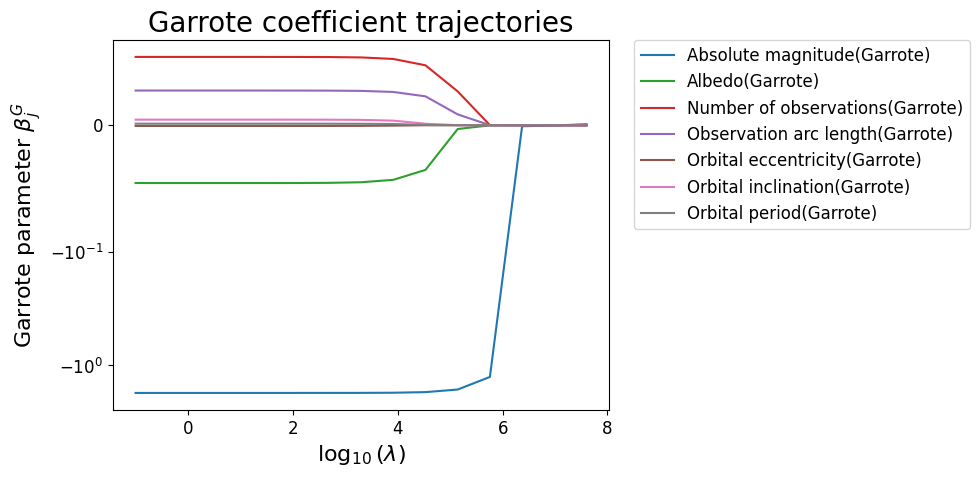

In [12]:
# S_lambda set
S_lambd = np.logspace(-1, 7.6, 15)

# record the parameters of each lambda
beta_list = []
ls_list = []

# train models of different lambda
for lambd in S_lambd:
    beta_G, beta, g, loss_history, epochs_list = train_garrote(X_train_std, y_train, lambd=lambd)
    beta_list.append(beta_G)
    ls_list.append(beta)

all_beta = np.vstack(beta_list) # (Number_of_lambda, Number_of_feature)
all_ls = np.vstack(ls_list)
feature_color = ['C0', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
# plot each feature
for j in range(all_beta.shape[1]):
    c = feature_color[j]
    plt.plot(np.log10(S_lambd), all_beta[:, j], color=c, label=features[j]+"(Garrote)")
    # plt.plot(np.log10(S_lambd), all_ls[:, j + 1], '--', color=c, label=features[j]+"(OLS)")

plt.yscale("symlog", linthresh=0.1)
plt.xlabel(r"$\log_{10}(\lambda)$")
plt.ylabel(r"Garrote parameter ${\beta}_j^{G}$")
plt.title("Garrote coefficient trajectories")
# plt.legend()
plt.legend(loc=2, bbox_to_anchor=(1.05,1.0),borderaxespad = 0.) 
plt.show()

<a name="task-12"></a>

## (1.2) [(index)](#index-task-12)

In [13]:
def T_fold_split(num_samples, num_folds):
    fold_size = num_samples // num_folds
    indices = np.arange(num_samples)
    folds = [indices[i * fold_size : (i + 1) * fold_size] for i in range(num_folds)]
    return folds

def T_fold_evaluation(X, y, num_folds, S_lambd):
    N, p = X.shape
    assert N == y.shape[0]

    folds = T_fold_split(N, num_folds)
    d_list = []
    for j, lambd in enumerate(S_lambd):
        val_mse_list = []
        for i, val_indice in enumerate(folds):
            # get train set and val set
            train_indices = np.setdiff1d(np.arange(N), val_indice)
            X_train, y_train = X[train_indices], y[train_indices]
            X_val, y_val = X[val_indice], y[val_indice]

            N_val = X_val.shape[0]
            assert N_val == len(val_indice)

            # train
            beta_G, beta, g, loss_history, epochs_list = train_garrote(X_train, y_train, lambd=lambd)

            # compute mse
            mse = np.sum((y_val - X_val @ beta_G - beta[0]) ** 2) / N_val
            val_mse_list.append(mse)

        sumation = 0
        for t in range(1, num_folds):
            sumation += abs(val_mse_list[t] - val_mse_list[t - 1])
        sumation /= num_folds - 1
        d_list.append(sumation)

    return d_list

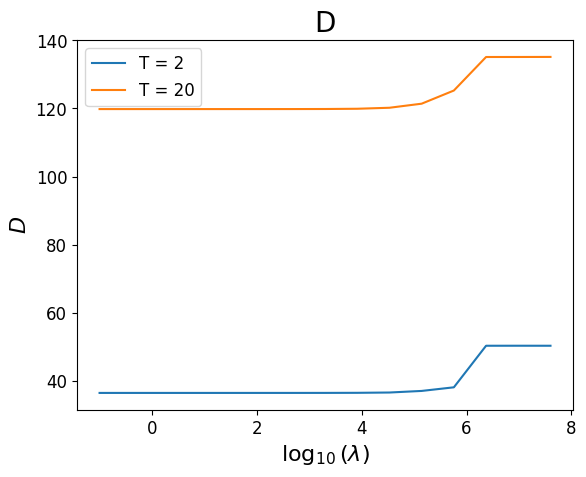

In [14]:
T_list = [2, 20]
for T in T_list:
    d_list = T_fold_evaluation(X_train_std, y_train, T, S_lambd)
    plt.plot(np.log10(S_lambd), d_list, label=r"T = "+f"{T}")

plt.xlabel(r"$\log_{10}(\lambda)$")
plt.ylabel(r"$D$")
plt.title("D")
plt.legend()
plt.show()

<a name="task-13"></a>

## (1.3) [(index)](#index-task-13)

In [15]:
# from week 1 notebook
def minimize_ls_huber(X, y, lambd, n_iters=10000, step_size=1e-7, c_huber=1e-4):
    """
    This function estimates the regression parameters with the relaxed version
    of LASSO regression using the gradient-descent algorithm to find the optimal
    solution.
    Args:
    X (np.array): The augmented data matrix with shape (N, p + 1).
    y (np.array): The response column with shape (N, 1).
    lambd (float): The multiplier of the relaxed L1 term.
    n_iters (int): Number of gradient descent iterations.
    step_size (float): The step size in the updating step.
    """

    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape
    X_aug = np.hstack((np.ones((N, 1)), X))
    # Precomputed products to avoid redundant computations.
    XX = X_aug.T @ X_aug
    Xy = X_aug.T @ y
    # Initialize beta params with zeros
    beta = np.zeros(p + 1)

    for i in range(n_iters):
        # Compute the gradient of the relaxed LASSO, Huber.
        grad_c = grad_huber(beta, c_huber)

        # Intercept term is not involved in the regularisation.
        grad_c[0] = 0 ## <-- EDIT THIS LINE

        # Compute the gradient of the regularised loss.
        grad = (2 / N) * (XX @ beta - Xy) + lambd * grad_c ## <-- EDIT THIS LINE

        # Update beta
        beta = beta - step_size * grad ## <-- EDIT THIS LINE

    return beta

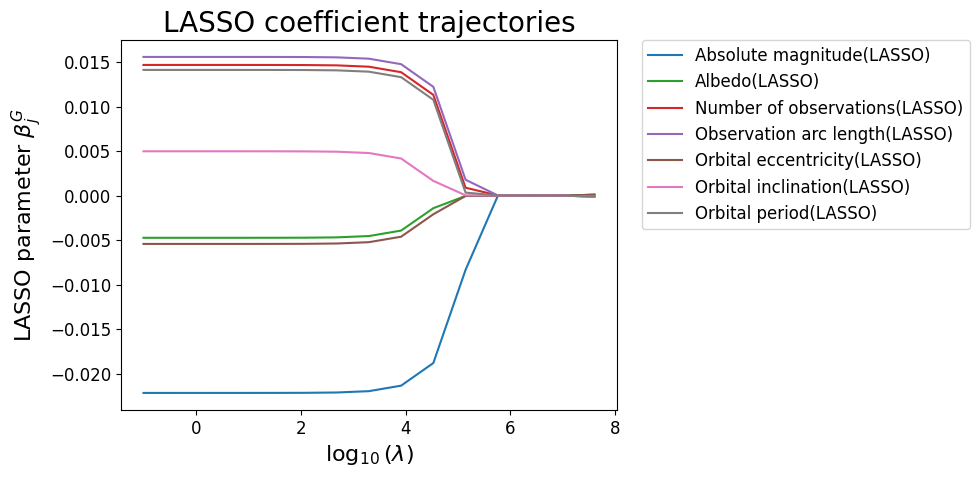

In [16]:
# record the parameters of each lambda
garrote_list = []
ls_list = []
lasso_list = []

# train models of different lambda
for lambd in S_lambd:
    beta_G, beta, g, loss_history, epochs_list = train_garrote(X_train_std, y_train, lambd=lambd)
    beta_lasso = minimize_ls_huber(X_train_std, y_train, lambd=lambd)
    beta_lasso_without_intercept = beta_lasso[1:]
    lasso_list.append(beta_lasso_without_intercept)
    garrote_list.append(beta_G)
    ls_list.append(beta)

all_lasso = np.vstack(lasso_list) # (Number_of_lambda, Number_of_feature)
all_ls = np.vstack(ls_list)
all_garrote = np.vstack(garrote_list)
feature_color = ['C0', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
# plot each feature
for j in range(all_lasso.shape[1]):
    c = feature_color[j]
    # plt.plot(np.log10(S_lambd), all_garrote[:, j], color=c, label=features[j]+"(Garrote)")
    plt.plot(np.log10(S_lambd), all_lasso[:, j], color=c, label=features[j]+"(LASSO)")
    # plt.plot(np.log10(S_lambd), all_ls[:, j + 1], '--', color=c, label=features[j]+"(OLS)")

plt.xlabel(r"$\log_{10}(\lambda)$")
plt.ylabel(r"LASSO parameter ${\beta}_j^{G}$")
plt.title("LASSO coefficient trajectories")
# plt.legend()
plt.legend(loc=2, bbox_to_anchor=(1.05,1.0),borderaxespad = 0.) 
plt.show()

In [17]:
def bootstrap_feature_selection(X, y, N_prime, lambd, B=100, n_iters=10000, step_size=1e-7, c_huber=1e-4):
    N, p = X.shape
    training_indices = np.arange(N)
    selection_counts = np.zeros(p)

    for b in range(B):
        indices = rng.choice(training_indices, size=N_prime, replace=False)
        X_sample = X[indices]
        y_sample = y[indices]

        beta_lasso = minimize_ls_huber(X_sample, y_sample, lambd, n_iters, step_size, c_huber)
        beta_lasso = beta_lasso[1:]
        selected = np.abs(beta_lasso) > 0.001
        selection_counts += selected

    return selection_counts / B

In [18]:
def plot_prob_trajectory(N_prime, S_lambd):
    prob_list = []

    # get prob of different lambda
    for lambd in S_lambd:
        prob_lasso = bootstrap_feature_selection(X_train_std, y_train, N_prime, lambd=lambd, B=100)
        prob_list.append(prob_lasso)

    all_prob = np.vstack(prob_list)
    feature_color = ['C0', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
    for j in range(all_prob.shape[1]):
        c = feature_color[j]
        plt.plot(np.log10(S_lambd), all_prob[:, j], color=c, label=features[j]+" Probability")

    plt.yscale("symlog", linthresh=0.1)
    plt.xlabel(r"$\log_{10}(\lambda)$")
    plt.ylabel(r"Probability")
    plt.title("LASSO selection")
    plt.legend(loc=2, bbox_to_anchor=(1.05,1.0),borderaxespad = 0.) 
    plt.xticks(rotation=45)
    plt.show()

def plot_prob_bar(N_prime, lambd):
    plt.figure(figsize=(12, 6))
    prob_lasso = bootstrap_feature_selection(X_train_std, y_train, N_prime, lambd=lambd, B=100)

    plt.bar(features, prob_lasso)
    plt.xlabel('Feature Index')
    plt.ylabel('LASSO prob')
    plt.title('LASSO Coefficients of Features')
    plt.xticks(rotation=45)
    plt.show()

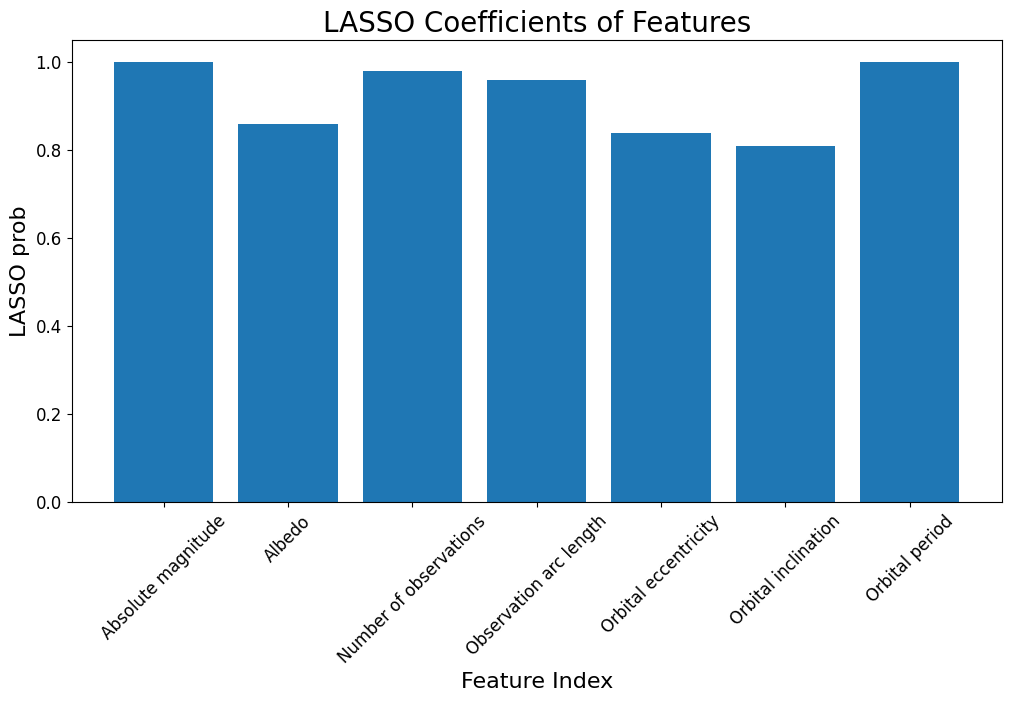

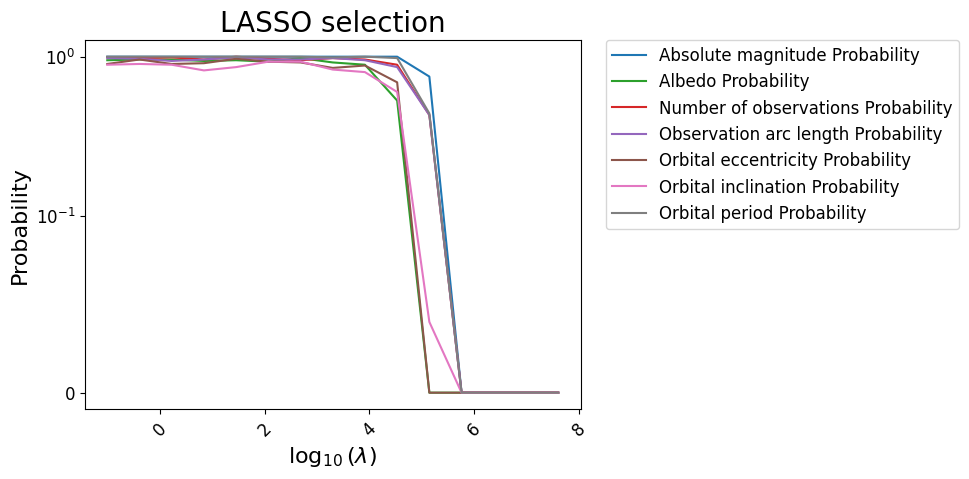

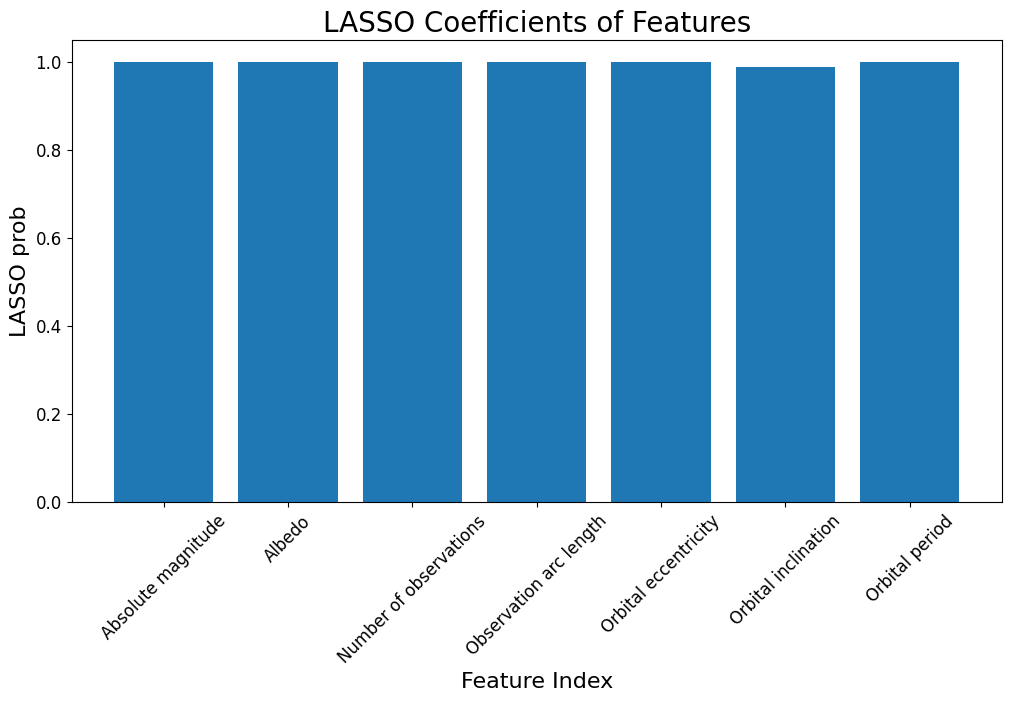

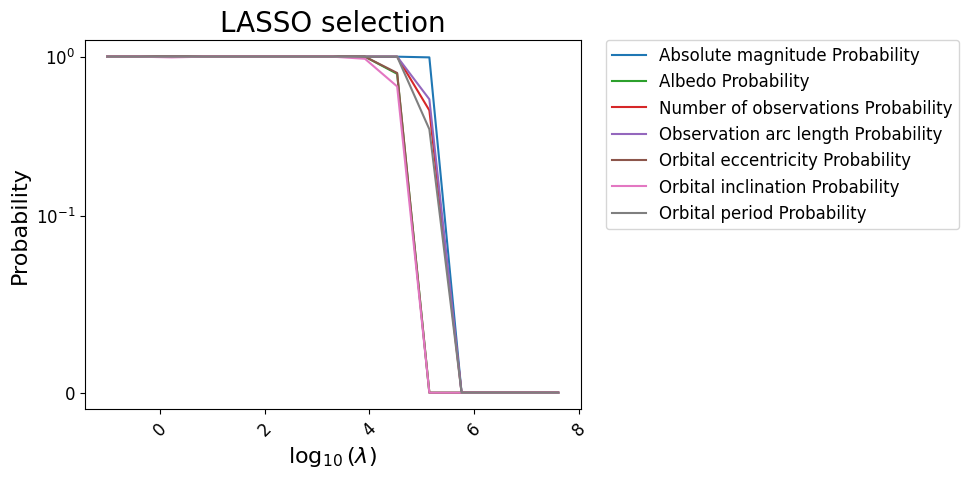

In [19]:
plot_prob_bar(50, S_lambd[8])
plot_prob_trajectory(50, S_lambd)

N_train = X_train_std.shape[0]
plot_prob_bar(N_train // 2, S_lambd[8])
plot_prob_trajectory(N_train // 2, S_lambd)

<a name="task-14"></a>

## (1.4) [(index)](#index-task-14)

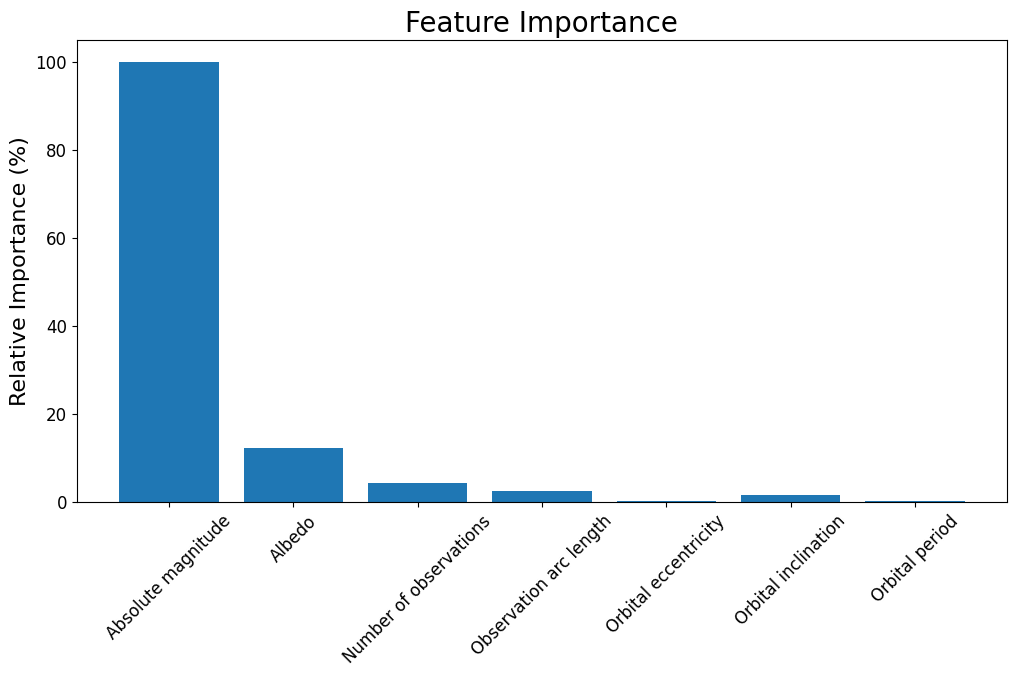

In [20]:
def compute_r2(y_true, y_pred):
    """R^2 score to assess regression performance."""

    # Adjustment to avoid subtraction between (K,) and (1, K) arrays.
    y_true = y_true.reshape(y_pred.shape)
    y_bar = y_true.mean()

    ss_tot = ((y_true - y_bar)**2).sum()
    ss_res = ((y_true - y_pred)**2).sum()
    return 1 - (ss_res/ss_tot)

def ls_importance(X_train, y_train, X_test, y_test):
    beta_ls = fit_ols(X_train, y_train)

    X_test_aug = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
    y_test_pred_base = X_test_aug @ beta_ls
    r2_baseline = compute_r2(y_test, y_test_pred_base)

    importance = []
    p = X_test.shape[1]

    for j in range(p):
        X_test_shuffled = X_test.copy()
        rng.shuffle(X_test_shuffled[:, j])

        X_test_shuffle_aug = np.hstack((np.ones((X_test.shape[0], 1)), X_test_shuffled))
        y_test_pred_shuffled = X_test_shuffle_aug @ beta_ls
        r2_shuffled = compute_r2(y_test, y_test_pred_shuffled)

        importance.append(abs(r2_baseline - r2_shuffled))

    importances = np.array(importance)
    max_imp = np.max(importances)
    importance_percent = (importances / max_imp) * 100

    return importance_percent

importance = ls_importance(X_train_std, y_train, X_test_std, y_test)
plt.figure(figsize=(12, 6))
plt.bar(features, importance)
plt.ylabel('Relative Importance (%)')
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()

<a name="task-2"></a>

# Task 2: Non-linear regression with Kernel Ridge Regression [(index)](#index-task-2)

<a name="task-21"></a>

## (2.1) [(index)](#index-task-21)

In [21]:
# from week 1 notebook
def fit_ridge(X, y, penalty):

    # X: N x p matrix of training inputs
    # y: N x 1 vector of training targets/observations
    # returns: maximum likelihood parameters ((p + 1) x 1)

    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape
    X_aug = np.hstack([np.ones((N,1)), X]) # augmented training inputs of size N x (p + 1)
    N_aug, p_aug = X_aug.shape
    I = np.identity(p_aug)
    I[0] = 0.0 # penalty excludes the bias term.
    beta_ridge = np.linalg.solve(X_aug.T @ X_aug / N + penalty * I, X_aug.T @ y / N) ## <-- EDIT THIS LINE
    return beta_ridge

def score_ridge(X_train, y_train, X_test, y_test, lambd=0.1):
    beta_ridge = fit_ridge(X_train, y_train, penalty=lambd)
    N_test, p = X_test.shape
    X_test_aug = np.hstack([np.ones((N_test,1)), X_test])
    y_test_pred = X_test_aug @ beta_ridge
    r2 = compute_r2(y_test, y_test_pred)
    return r2

In [22]:
print(score_ridge(X_train_std, y_train, X_test_std, y_test, lambd=0.1))
print(score_ridge(X_train_std, y_train, X_train_std, y_train, lambd=0.1))

0.746036091143093
0.750465814764694


$$
\underset{\boldsymbol\beta}{\text{min}} \frac{1}{N^{\text{train}}} \| \boldsymbol y - \boldsymbol X \boldsymbol\beta \|^2 + \lambda \| \boldsymbol\beta \|^2
$$

$$
\underset{\boldsymbol\beta}{\text{min}} \frac{1}{N^{\text{train}}} \| \boldsymbol y - \boldsymbol\phi(\boldsymbol X )\boldsymbol\beta_{\phi} \|^2 + \lambda \| \boldsymbol\beta_{\boldsymbol\phi} \|^2
$$

introduce vector $\mathbf{u}$
$$
\boldsymbol{\beta}_{\boldsymbol \phi} = \sum_{i = 1}^{N} \boldsymbol\phi({\mathbf{x}^{(i)}}) u_i
$$

$$
\boldsymbol{\beta}_{\boldsymbol \phi} \cdot \boldsymbol\phi({\boldsymbol{X}^T}) = \mathbf{u}^T \mathbf{K}
$$

$$
\| \boldsymbol{\beta}_{\boldsymbol \phi} \|^2 = \boldsymbol{\beta}_{\boldsymbol \phi} \cdot \boldsymbol{\beta}_{\boldsymbol \phi} = \mathbf{u}^T \mathbf{K} \mathbf{u}
$$

optimise on $\mathbf{u}$
$$
\underset{\boldsymbol\beta}{\text{min}} \frac{1}{N^{\text{train}}} \| \boldsymbol y - \mathbf{K} \mathbf{u} \|^2 + \lambda \mathbf{u}^T \mathbf{K} \mathbf{u}
$$

$$
(\frac{\mathbf{K}^T\mathbf{K}}{N}+ \lambda \mathbf{K})\mathbf{u}^{*}_{\text{ridge}} = \frac{\boldsymbol K^T\boldsymbol y}{N}
$$

since $\mathbf{K}$ is symetric
$$
(\frac{\mathbf{K}}{N}+ \lambda \mathbf{I})\mathbf{u}^{*}_{\text{ridge}} = \frac{\boldsymbol y}{N}
$$

In [23]:
def kernel_matrix(X1, X2, n=2, c=1):
    n1, m1 = X1.shape
    n2, m2 = X2.shape
    kernel = np.zeros((n1, n2))

    for i in range(n1):
        v = X1[i, :]
        dot_product = np.dot(v, X2.T) + c
        kernel[i,:] = dot_product ** n

    return kernel

def fit_kernal_ridge(X, y, penalty, n, c):
    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape
    K = kernel_matrix(X, X, n, c)
    I = np.identity(N)
    u_ridge = np.linalg.solve(K / N + penalty * I, y / N)
    assert u_ridge.shape[0] == N
    return u_ridge

def score_kernal_ridge(X_train, y_train, X_test, y_test, lambd, n, c):
    u_ridge = fit_kernal_ridge(X_train, y_train, lambd, n, c)

    K_test = kernel_matrix(X_test, X_train, n, c)
    y_test_pred = K_test @ u_ridge
    r2 = compute_r2(y_test, y_test_pred)
    return r2

In [24]:
n, c = 2, 0
print(f"n = {n}, c = {c}, test set R^2 score: ", score_kernal_ridge(X_train_std, y_train, X_test_std, y_test, lambd=0.1, n=n, c=c))
print(f"n = {n}, c = {c}, train set R^2 score: ", score_kernal_ridge(X_train_std, y_train, X_train_std, y_train, lambd=0.1, n=n, c=c))
n, c = 2, 1
print(f"n = {n}, c = {c}, test set R^2 score: ", score_kernal_ridge(X_train_std, y_train, X_test_std, y_test, lambd=0.1, n=n, c=c))
print(f"n = {n}, c = {c}, train set R^2 score: ", score_kernal_ridge(X_train_std, y_train, X_train_std, y_train, lambd=0.1, n=n, c=c))
n, c = 3, 1
print(f"n = {n}, c = {c}, test set R^2 score: ", score_kernal_ridge(X_train_std, y_train, X_test_std, y_test, lambd=0.1, n=n, c=c))
print(f"n = {n}, c = {c}, train set R^2 score: ", score_kernal_ridge(X_train_std, y_train, X_train_std, y_train, lambd=0.1, n=n, c=c))

n = 2, c = 0, test set R^2 score:  0.6175788574986603
n = 2, c = 0, train set R^2 score:  0.7442772950233124
n = 2, c = 1, test set R^2 score:  0.947743591512433
n = 2, c = 1, train set R^2 score:  0.953255587713263
n = 3, c = 1, test set R^2 score:  0.9759929264269608
n = 3, c = 1, train set R^2 score:  0.9843306895540649


<a name="task-22"></a>

## (2.2) [(index)](#index-task-22)

$$
k^{new}(\boldsymbol v, \boldsymbol z) = e ^ {-\frac{\| \boldsymbol{\phi}^{{P}}(\boldsymbol v) - \boldsymbol{\phi}^{{P}}(\boldsymbol z) \|^2}{\sigma}}
$$

$$
\| \boldsymbol{\phi}^{{P}}(\boldsymbol v) - \boldsymbol{\phi}^{{P}}(\boldsymbol z) \|^2 = 
(\boldsymbol{\phi}^{{P}}(\boldsymbol v) - \boldsymbol{\phi}^{{P}}(\boldsymbol z))^T (\boldsymbol{\phi}^{{P}}(\boldsymbol v) - \boldsymbol{\phi}^{{P}}(\boldsymbol z)) \\  
= \boldsymbol{\phi}^{{P}}(\boldsymbol v)^T \boldsymbol{\phi}^{{P}}(\boldsymbol v) + \boldsymbol{\phi}^{{P}}(\boldsymbol z)^T \boldsymbol{\phi}^{{P}}(\boldsymbol z) - 2 \boldsymbol{\phi}^{{P}}(\boldsymbol v)^T \boldsymbol{\phi}^{{P}}(\boldsymbol z) \\
= k^{P}(\boldsymbol v, \boldsymbol v) + k^{P}(\boldsymbol z, \boldsymbol z) - 2 k^{P}(\boldsymbol v, \boldsymbol z)
$$

$$
k^{new}(\boldsymbol v, \boldsymbol z) = e ^ {-\frac{k^{P}(\boldsymbol v, \boldsymbol v) + k^{P}(\boldsymbol z, \boldsymbol z) - 2 k^{P}(\boldsymbol v, \boldsymbol z)}{\sigma}}
$$

In [25]:
def rbf_kernel_matrix(X1, X2, sigma=20):
    """
    Calculates the kernel matrix given the data.

    Parameters:
        X1, X2 (np.array): Two sets of input features.
        sigma (float): Hyperparameter in Gaussian kernel.

    Returns:
        kernel (np.array): Kernel Matrix.
    """
    n1, m1 = X1.shape
    n2, m2 = X2.shape
    kernel = np.zeros((n1, n2))

    # Here we define a Gaussian Radial Basis Function Kernel
    for i in range(n1):
        exponent = np.linalg.norm(X1[i, :] - X2, axis=1) ** 2 ## <-- EDIT THIS LINE
        kernel[i,:] = np.exp(-exponent / sigma)

    return kernel

def new_kernal_matrix(X1, X2, sigma=20, n=2, c=1):
    n1, m1 = X1.shape
    n2, m2 = X2.shape

    k_P_v = (X1 @ X1.T + c) ** n
    k_P_z = (X2 @ X2.T + c) ** n
    k_P_vz = (X1 @ X2.T + c) ** n

    exponent = np.zeros((n1, n2))
    for i in range(n1):
        for j in range(n2):
            exponent[i, j] = k_P_v[i, i] + k_P_z[j, j] - 2 * k_P_vz[i, j]

    kernel = np.exp(-exponent / sigma)
    return kernel

def fit_gernal_kernal_ridge(X, y, penalty, kernal_type, sigma=20, n=2, c=1):
    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape
    if kernal_type == "p":
        K = kernel_matrix(X, X, n=n, c=c)
    elif kernal_type == "rbf":
        K = rbf_kernel_matrix(X, X, sigma=sigma)
    elif kernal_type == "new":
        K = new_kernal_matrix(X, X, sigma=sigma, n=n, c=c)

    I = np.identity(N)
    u_ridge = np.linalg.solve(K / N + penalty * I, y / N)
    assert u_ridge.shape[0] == N
    return u_ridge

def score_gernal_kernal_ridge(X_train, y_train, X_test, y_test, lambd, kernal_type, sigma=20, n=2, c=1):
    u_ridge = fit_gernal_kernal_ridge(X_train, y_train, lambd, kernal_type, sigma, n, c)

    if kernal_type == "p":
        K_test = kernel_matrix(X_test, X_train, n=n, c=c)
    elif kernal_type == "rbf":
        K_test = rbf_kernel_matrix(X_test, X_train, sigma=sigma)
    elif kernal_type == "new":
        K_test = new_kernal_matrix(X_test, X_train, sigma=sigma, n=n, c=c)
    y_test_pred = K_test @ u_ridge
    r2 = compute_r2(y_test, y_test_pred)
    return r2

def plot_krr_3d(X_train, y_train, lambd, kernel_type, sigma=20, n=2, c=1):
    X_train_2d = X_train[:, :2]
    u_ridge= fit_gernal_kernal_ridge(X_train_2d, y_train, lambd, kernel_type, sigma, n, c)

    x1_min, x1_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
    x2_min, x2_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 30), 
                           np.linspace(x2_min, x2_max, 30))
    
    X_grid = np.c_[xx1.ravel(), xx2.ravel()]
    
    if kernel_type == "p":
        K_grid = kernel_matrix(X_grid, X_train_2d, n, c)
    elif kernel_type == "rbf":
        K_grid = rbf_kernel_matrix(X_grid, X_train_2d, sigma)
    elif kernel_type == "new":
        K_grid = new_kernal_matrix(X_grid, X_train_2d, sigma, n, c)
        
    y_grid_pred = (K_grid @ u_ridge).reshape(xx1.shape)
    
    # plot
    fig = plt.figure(figsize=(14, 7))
    ax = fig.add_subplot(projection='3d')
    
    # plot train
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], y_train, color='red', label='Data Points', alpha=0.6)
    
    # plot pred
    ax.plot_surface(xx1, xx2, y_grid_pred, cmap='viridis', alpha=0.5, edgecolor='none')
    ax.view_init(elev=20, azim=-60)
    
    ax.set_xlabel('Absolute Magnitude')
    ax.set_ylabel('Albedo')
    ax.set_zlabel('Asteroid Diameter')
    ax.set_title(f"Kernel: {kernel_type}, " + r"$\lambda$: " + f"{lambd}")
    plt.show()

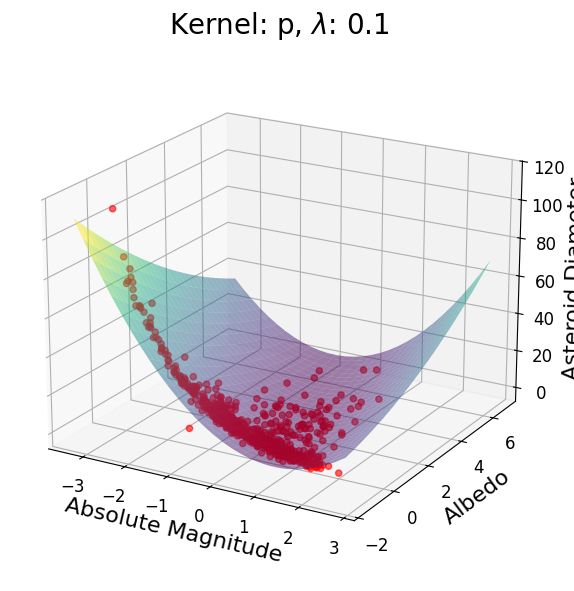

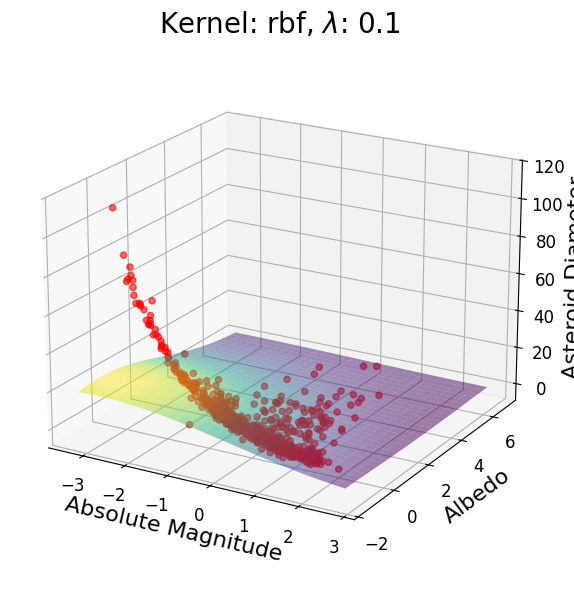

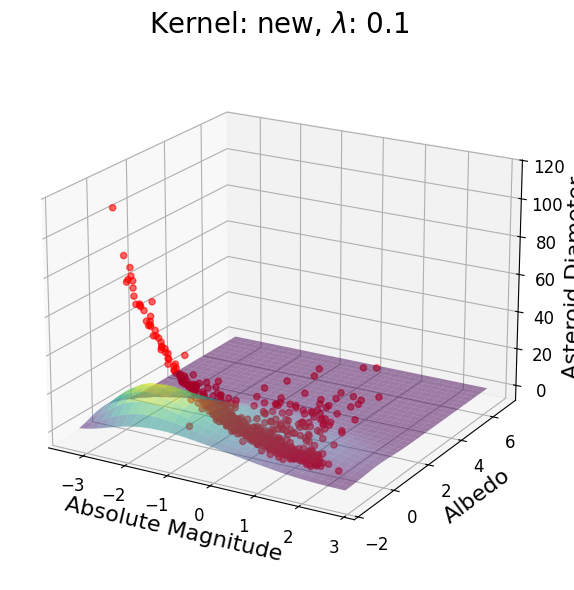

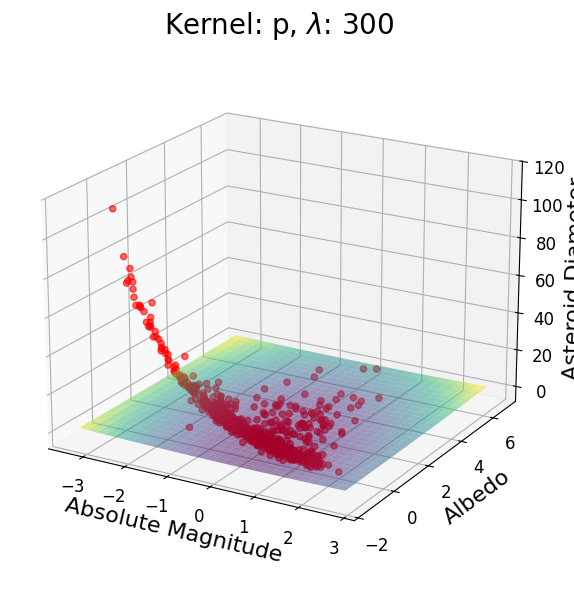

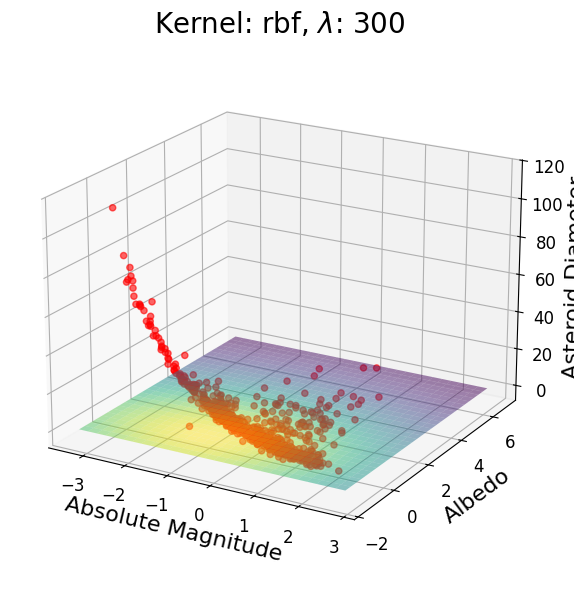

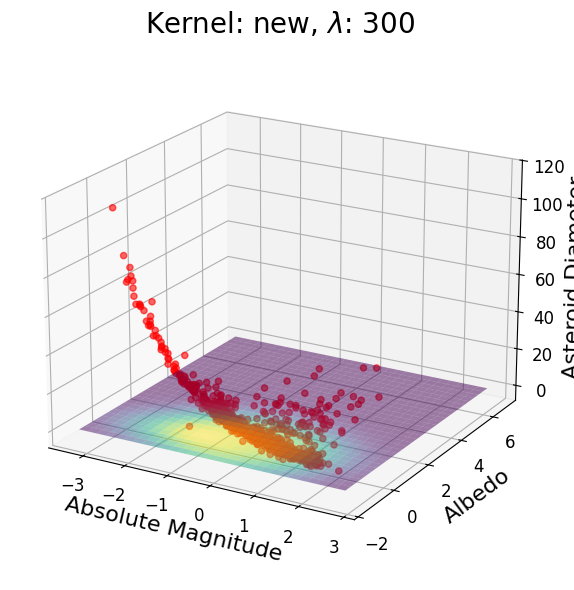

In [26]:
plot_krr_3d(X_train_std, y_train, 0.1, "p")
plot_krr_3d(X_train_std, y_train, 0.1, "rbf")
plot_krr_3d(X_train_std, y_train, 0.1, "new")
plot_krr_3d(X_train_std, y_train, 300, "p")
plot_krr_3d(X_train_std, y_train, 300, "rbf")
plot_krr_3d(X_train_std, y_train, 300, "new")

In [27]:
print(score_gernal_kernal_ridge(X_train_std[:, :2], y_train, X_train_std[:, :2], y_train, 0.1, 'p', sigma=20, n=2, c=1))
print(score_gernal_kernal_ridge(X_train_std[:, :2], y_train, X_train_std[:, :2], y_train, 0.1, 'rbf', sigma=20, n=2, c=1))
print(score_gernal_kernal_ridge(X_train_std[:, :2], y_train, X_train_std[:, :2], y_train, 0.1, 'new', sigma=20, n=2, c=1))
print(score_gernal_kernal_ridge(X_train_std[:, :2], y_train, X_train_std[:, :2], y_train, 300, 'p', sigma=20, n=2, c=1))
print(score_gernal_kernal_ridge(X_train_std[:, :2], y_train, X_train_std[:, :2], y_train, 300, 'rbf', sigma=20, n=2, c=1))
print(score_gernal_kernal_ridge(X_train_std[:, :2], y_train, X_train_std[:, :2], y_train, 300, 'new', sigma=20, n=2, c=1))

0.9503704611002955
0.4219633288626309
0.3960551367124596
-0.7456085793543004
-0.7803514683772905
-0.7820365661651816


<a name="task-3"></a>

# Task 3: Classification with the Multi-Layer Perceptron [(index)](#index-task-3)

In [154]:
def mse_loss(y_true, y_pred):
    """Compute MSE-loss

    Parameters:
        y_true: ground-truth array, with shape (K, )
        y_pred: predictions array, with shape (K, )

    Returns:
        loss (float): MSE-loss
    """
    assert y_true.size == y_pred.size, "Ground-truth and predictions have different dimensions."

    # Adjustment to avoid subtraction between (K,) and (1, K) arrays.
    y_true = y_true.reshape(y_pred.shape)

    # Compute MSE loss
    loss = np.mean((y_true - y_pred) ** 2, keepdims=True) ## <-- EDIT THIS LINE
    return loss

def grad_mse_loss(y_true, y_pred):
    """Compute gradient of MSE-loss

    Parameters:
        y_true: ground-truth values, shape: (K, ).
        y_pred: prediction values, shape: (K, ).

    Returns:
        grad (np.ndarray): Gradient of MSE-loss, shape: (K, ).
    """
    # Adjustment to avoid subtraction between (K,) and (1, K) arrays.
    y_true = y_true.reshape(y_pred.shape)

    # Compute gradient of MSE loss
    grad = 2.0 * (y_pred - y_true) / y_true.size ## <-- EDIT THIS LINE
    return grad

In [155]:
def dense(X, W, b):
    """Full-connected MLP layer.

    Parameters:
        X (np.ndarray): K x h_in array of inputs, where K is the batch size and h_in is the input dimension.
        W (np.ndarray): h_out x h_in array for weights matrix parameters, where h_out is the output dimension.
        b (np.ndarray): Length h_out 1-D array for bias parameters

    Returns:
        a (np.ndarray): K x h_out array of pre-activations
    """
    a = X @ W.T + b ## <-- EDIT THIS LINE
    return a

def relu_activation(a):
    """ReLU activation function.

    Parameters:
        a: K x h_out array of pre-activations

    Returns:
        h: K x h_out array of post-activations
    """
    # compute post-activations
    h = np.maximum(a, 0.)  ## <-- EDIT THIS LINE
    return h

def grad_relu_activation(a):
    """Gradient of ReLU activation function.

    Parameters:
        a: K x h_out array of pre-activations

    Returns:
        grad: K x h_out gradient array of post-activations
    """
    # compute gradient
    grad = np.where(a < 0, 0, 1) ## <-- EDIT THIS LINE
    return grad

def softmax(a, axis=1):
    exp = np.exp(a)
    return exp / np.sum(exp, axis=axis, keepdims=True)

# A lookup table for activation functions by their names.
activation_table = {
    "relu": relu_activation,
    # Identity function.
    "identity": lambda x: x
}

# A lookup table for gradient of activation functions by their names.
grad_activation_table = {
    "relu": grad_relu_activation,
    # Identity function gradient.
    "identity": lambda x: np.ones_like(x)
}



In [156]:
class MLP:
    """
    This class represents a Multi-Layer Perceptron (MLP), that we are going
    to use to encapsulate two components:
        1. layers: the sequence of layers, where each layer is stored in
            a dictionary in the format {"W": np.ndarray, "b": np.ndarray},
            where "W" points to the weights array, and "b" points to
            the bias vector.
        2. rng: a pseudo random number generator (RNG) initialised to generate
            the random weights in a reproducible manner between different
            runtime sessions.
    This class is also shipped with methods that perform essential operations
    with a MLP, including:
        - add_layers: which creates a new layer with specified dimensions.
        - predict: applies the MLP forward pass to make predictions and produces
            a computational graph for the forward pass that can be used to
            compute gradients using backpropagation algorithm.
        in addition to other light functions that return simple statistics about
        the MLP.
    """
    def __init__(self, seed=42):
        self.layers = []
        self.rng = np.random.default_rng(seed)

    def n_parameters(self):
        """Return the total number of parameters of weights and biases."""
        return sum(l["b"].size + l["W"].size for l in self.layers)

    def n_layers(self):
        """Return current number of MLP layers."""
        return len(self.layers) + 1 if len(self.layers) > 0 else 0

    def layer_dim(self, index):
        """Retrieve the dimensions of the MLP layer at `index`."""
        return self.layers[index]["W"].shape

    def add_layer(self, in_dim, out_dim, activation="identity"):
        """Add fully connected layer to MLP.

        Parameters:
            in_dim (int): The input dimension of the layer.
            out_dim (int): The output dimension of the layer.
            activation (str): The activation function name.
        """
        # check if input-dimension matches output-dimension of previous layer
        if self.n_layers() > 0:
            last_out_dim, _ = self.layer_dim(-1)
            assert in_dim == last_out_dim, f"Input-dimension {in_dim} does not match output-dimension {last_out_dim} of previous layer."

        # the first layer, in our convention illustrated, does not apply activation on the input features X.
        if self.n_layers() == 0:
            assert activation == "identity", "Should not apply activations on the input features X, use Identity function for the first layer."


        # store each layer as a dictionary in the list, as shown in the
        # attached diagram.
        self.layers.append({
            # only for debugging.
            "index": len(self.layers),
            # apply Glorot initialisation for weights.
            # hint: use self.rng.normal()
            "W": self.rng.normal(size=(out_dim, in_dim)) * np.sqrt(2. / (in_dim + out_dim)), ## <-- EDIT THIS LINE
            # initialise bias vector with zeros.
            "b": np.zeros(out_dim), ## <-- EDIT THIS LINE
            # store the activation function (as string)
            "activation": activation
        })

    def predict(self, X):
        """
        classification
        """
        # We assume that we work with a batch of examples (ndim==2).
        if X.ndim == 1:
            # If one example passed, add a dummy dimension for the batch.
            X = X.reshape(1, -1)

        # store pre- and post-activations in list
        forward_pass = [{"index": 0, "a": X, "h": X}]

        # iterate through hidden layers
        for k in range(1, len(self.layers)):
            # compute pre-activations
            a = dense(forward_pass[-1]["h"], self.layers[k - 1]["W"], self.layers[k - 1]["b"]) ## <-- EDIT THIS LINE
            activation = activation_table[self.layers[k]["activation"]] ## <-- EDIT THIS LINE
            forward_pass.append({"index": k, "a" : a, "h" : activation(a)})

        logits = dense(forward_pass[-1]["h"], self.layers[-1]["W"], self.layers[-1]["b"]) ## <-- EDIT THIS LINE

        probs = softmax(logits, axis=1)
        # predicted target is output of last layer
        return probs, logits, forward_pass

In [157]:
def cross_entropy_loss(y_true, y_prob):
    assert y_true.shape == y_prob.shape
    loss = -np.sum(np.sum(y_true * np.log(y_prob), axis=1), keepdims=True)
    return loss

def grad_cross_entropy_loss(y_true, y_prob):
    return y_prob - y_true

def backpropagate(layers, forward_pass, delta_output):
    gradients = []
    delta = delta_output

    assert len(layers) == len(forward_pass)

    for layer, forward_computes in reversed(list(zip(layers, forward_pass))):
        assert forward_computes["index"] == layer["index"], "Mismatch in the index."

        h = forward_computes["h"]
        assert delta.shape[0] == h.shape[0]

        # grads: average over batch
        gradients.append({
            "W": (delta.T @ h) / h.shape[0],
            "b": delta.mean(axis=0),
        })

        # backprop delta to previous layer
        grad_activation_f = grad_activation_table[layer["activation"]]
        grad_activation = grad_activation_f(forward_computes["a"])  # shape (K, in_dim of this layer)

        # vectorized: δ_prev = (δ @ W) ⊙ σ'(a)
        delta = (delta @ layer["W"]) * grad_activation

    gradients = list(reversed(gradients))
    return gradients

In [158]:
def sgd_step(X, y, mlp, learning_rate=1e-3, loss="ce"):
    """
    SGD step for multi-class classification (softmax + cross entropy).

    X: (K, p)
    y: (K, C) one-hot
    """
    # forward: probs
    probs, logits, forward_pass = mlp.predict(X)  ## <-- EDIT THIS LINE

    # delta at logits
    if loss == "ce":
        delta_output = grad_cross_entropy_loss(y, probs)           ## <-- EDIT THIS LINE
    elif loss == "mse":
        delta_output = grad_mse_loss(y, logits)

    gradients = backpropagate(mlp.layers, forward_pass, delta_output)

    updated_layers = []
    for layer, grad in zip(mlp.layers, gradients):
        W = layer["W"] - learning_rate * grad["W"]
        b = layer["b"] - learning_rate * grad["b"]
        updated_layers.append({
            "W": W, "b": b,
            "activation": layer["activation"],
            "index": layer["index"]
        })
    return updated_layers

def accuracy_from_onehot(y_true_onehot, y_prob):
    y_true = np.argmax(y_true_onehot, axis=1)
    y_pred = np.argmax(y_prob, axis=1)
    return np.mean(y_true == y_pred)

def sgd(X_train, y_train, X_test, y_test, mlp, learning_rate=1e-3,
        n_epochs=10, minibatchsize=1, seed=42):
    """
    SGD for multi-class classification using softmax + cross entropy.
    """
    rng = np.random.default_rng(seed)

    n_iterations = int(len(y_train) / minibatchsize)

    losses_train = []
    losses_test = []
    accs_train = []
    accs_test = []

    for i in range(n_epochs):

        # shuffle
        perm = rng.permutation(len(y_train))
        X_train_shuffled = X_train[perm]
        y_train_shuffled = y_train[perm]

        for j in range(n_iterations):
            X_batch = X_train_shuffled[j*minibatchsize:(j+1)*minibatchsize]
            y_batch = y_train_shuffled[j*minibatchsize:(j+1)*minibatchsize]

            updated_layers = sgd_step(X_batch, y_batch, mlp, learning_rate)  ## <-- EDIT THIS LINE
            mlp.layers = updated_layers                                      ## <-- EDIT THIS LINE

        # epoch-end metrics
        y_prob_train, _, _ = mlp.predict(X_train)
        loss_train = cross_entropy_loss(y_train, y_prob_train).squeeze()
        acc_train = accuracy_from_onehot(y_train, y_prob_train)

        y_prob_test, _, _ = mlp.predict(X_test)
        loss_test = cross_entropy_loss(y_test, y_prob_test).squeeze()
        acc_test = accuracy_from_onehot(y_test, y_prob_test)

        losses_train.append(loss_train)
        losses_test.append(loss_test)
        accs_train.append(acc_train)
        accs_test.append(acc_test)

        if (i == 0) or ((i + 1) % 50 == 0):
            print(
                f"Epoch {i+1}/{n_epochs}: "
                f"Train CE: {loss_train:.4f}, Test CE: {loss_test:.4f}, "
                f"Train Acc: {acc_train:.2%}, Test Acc: {acc_test:.2%}."
            )

    return mlp, losses_train, losses_test, accs_train, accs_test


<a name="task-31"></a>

## (3.1) [(index)](#index-task-31)

In [159]:
label_id = {"MBA": 0, "OMB": 1, "TJN": 2}
id_label = ["MBA", "OMB", "TJN"]

y_class_train_label = np.asarray(data_train.loc[:, 'Asteroid class'].map(label_id))
y_class_test_label = np.asarray(data_test.loc[:, 'Asteroid class'].map(label_id))

In [160]:
def one_hot(y, num_class):
    N = y.shape[0]
    y_onehot = np.zeros((N, num_class))
    for i in range(N):
        y_onehot[i, y[i]] = 1
    return y_onehot

y_class_train_onehot = one_hot(y_class_train_label, 3)
y_class_test_onehot = one_hot(y_class_test_label, 3)

In [161]:
mlp = MLP(seed=42)
mlp.add_layer(X_train_std.shape[1], 64)
mlp.add_layer(64, 64, 'relu')
mlp.add_layer(64, 32, 'relu')
mlp.add_layer(32, 3, 'relu')
print("Number of layers (including input and output layer):",mlp.n_layers())
print("Number of trainable parameters:",mlp.n_parameters())

mlp, losses_train, losses_test, accs_train, accs_test = sgd(
    X_train_std, y_class_train_onehot, X_test_std, y_class_test_onehot, mlp, learning_rate=0.04, n_epochs=500, minibatchsize=64
)

Number of layers (including input and output layer): 5
Number of trainable parameters: 6851
Epoch 1/500: Train CE: 661.0447, Test CE: 166.5123, Train Acc: 52.35%, Test Acc: 49.38%.
Epoch 50/500: Train CE: 106.4057, Test CE: 34.2652, Train Acc: 93.42%, Test Acc: 91.25%.
Epoch 100/500: Train CE: 52.8235, Test CE: 21.5966, Train Acc: 97.49%, Test Acc: 95.00%.
Epoch 150/500: Train CE: 33.7014, Test CE: 16.5859, Train Acc: 98.43%, Test Acc: 96.25%.
Epoch 200/500: Train CE: 23.0833, Test CE: 12.4526, Train Acc: 98.59%, Test Acc: 96.88%.
Epoch 250/500: Train CE: 16.6550, Test CE: 13.9724, Train Acc: 99.53%, Test Acc: 98.12%.
Epoch 300/500: Train CE: 14.0344, Test CE: 11.5169, Train Acc: 98.75%, Test Acc: 98.12%.
Epoch 350/500: Train CE: 8.3185, Test CE: 11.5614, Train Acc: 99.84%, Test Acc: 97.50%.
Epoch 400/500: Train CE: 9.0417, Test CE: 14.1510, Train Acc: 99.53%, Test Acc: 97.50%.
Epoch 450/500: Train CE: 14.4891, Test CE: 19.6091, Train Acc: 98.75%, Test Acc: 96.25%.
Epoch 500/500: Train

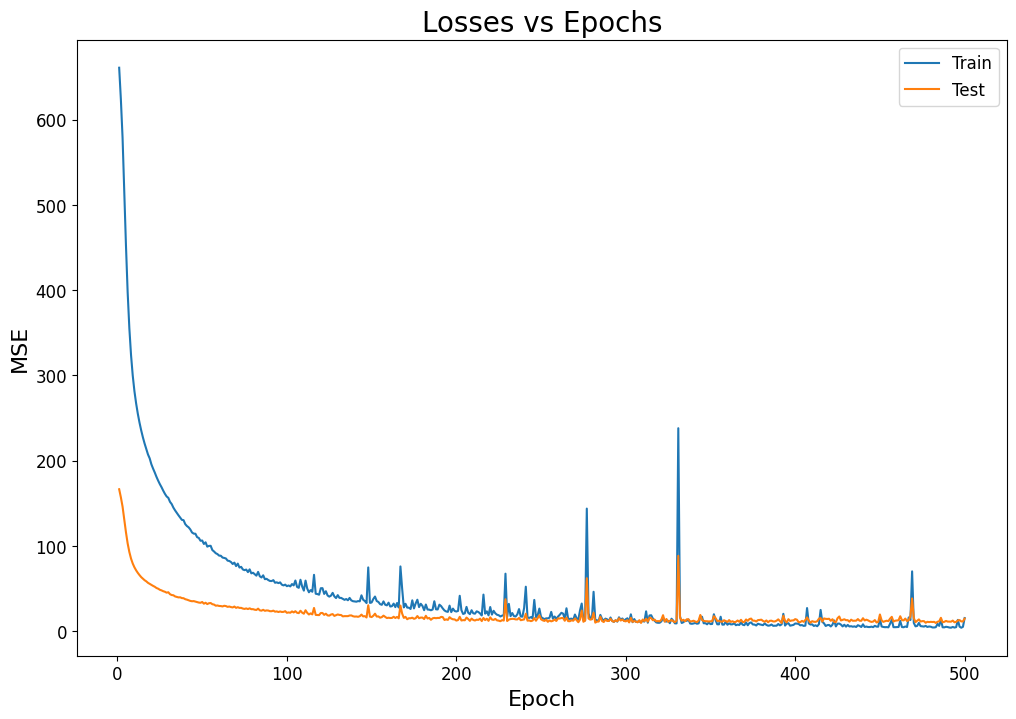

In [162]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(np.arange(1,501),losses_train, label="Train")
ax.plot(np.arange(1,501),losses_test, label="Test")
ax.set(title="Losses vs Epochs", xlabel = "Epoch", ylabel = "MSE")
ax.legend()
plt.show()

In [163]:
probs_test, _, _ = mlp.predict(X_test_std)   # (N_test, 3)
y_true = np.argmax(y_class_test_onehot, axis=1)

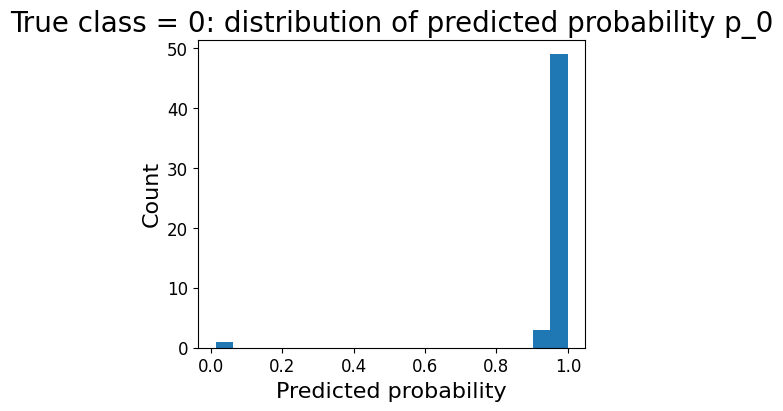

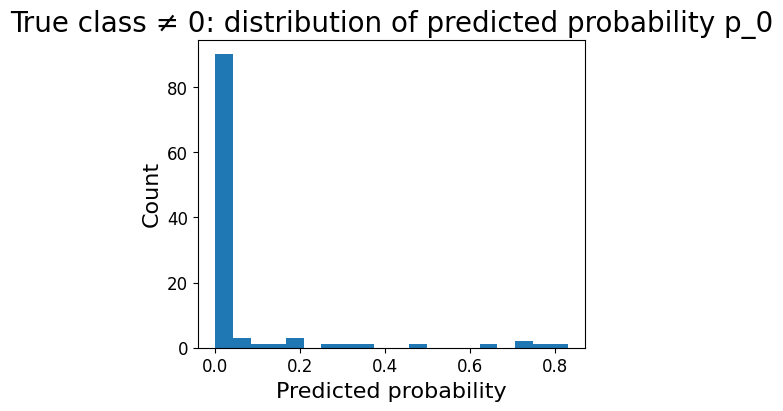

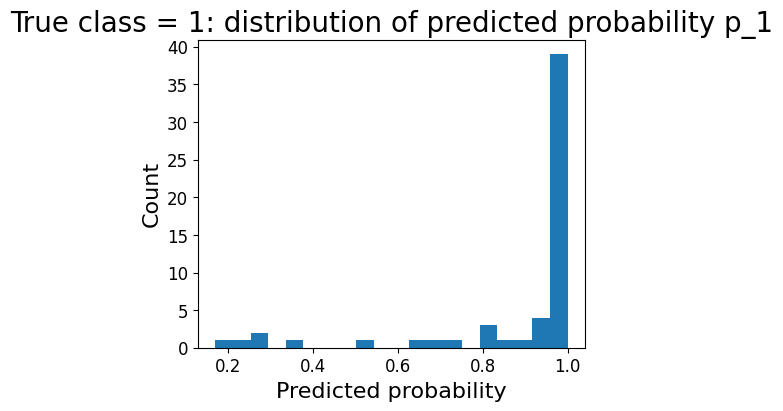

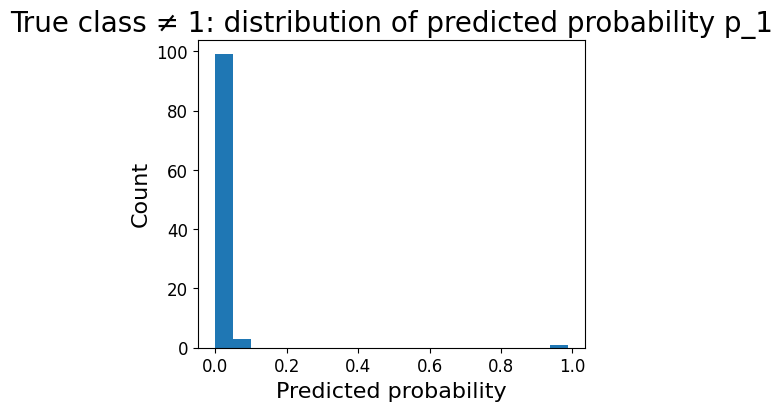

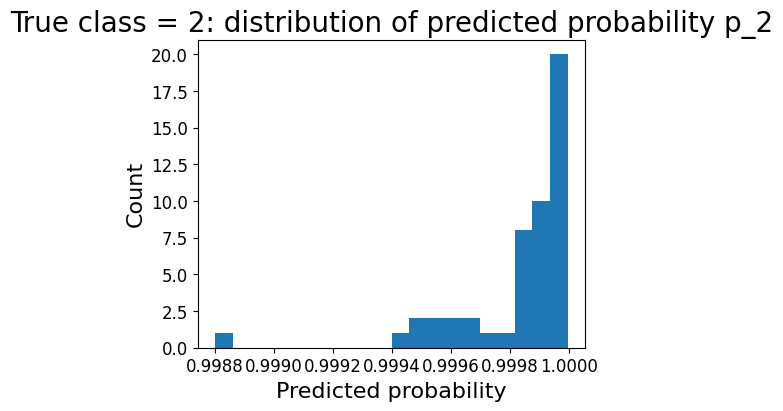

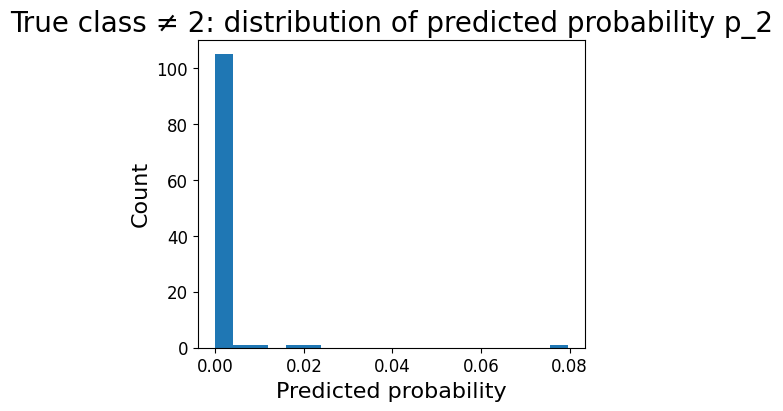

In [164]:
for q in range(3):

    p_q = probs_test[:, q]

    mask_true = (y_true == q)
    mask_false = (y_true != q)

    plt.figure(figsize=(5,4))
    plt.hist(p_q[mask_true], bins=20)
    plt.title(f"True class = {q}: distribution of predicted probability p_{q}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(5,4))
    plt.hist(p_q[mask_false], bins=20)
    plt.title(f"True class ≠ {q}: distribution of predicted probability p_{q}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.show()

<a name="task-32"></a>

## (3.2) [(index)](#index-task-32)

In [165]:
def train_weak_mlp(X, residual, weak_mlp, learning_rate=0.05, n_epochs=1000, minibatchsize=32, seed=42):
    rng = np.random.default_rng(seed)
    n_iterations = int(len(residual) / minibatchsize)
    losses_train = []

    for i in range(n_epochs):
        p = rng.permutation(len(residual))
        X_shuffled = X[p]
        y_shuffled = residual[p]

        for j in range(n_iterations):
            X_batch = X_shuffled[j*minibatchsize : (j+1)*minibatchsize]
            y_batch = y_shuffled[j*minibatchsize : (j+1)*minibatchsize]
            updated_layers = sgd_step(X_batch, y_batch, weak_mlp, learning_rate, "mse")
            weak_mlp.layers = updated_layers

        y_hat_train, _, _ = weak_mlp.predict(X)
        loss_train = mse_loss(residual, y_hat_train).squeeze()
        losses_train.append(loss_train)

        if (i==0) or ((i+1)%200==0):
            print(f'Epoch {i+1}/{n_epochs}: MSE: {loss_train:.6f}')

    return weak_mlp, losses_train

In [166]:
def evaluate_logits(a, y):
    p = softmax(a)
    y_true = np.argmax(y, axis=1)
    y_pred = np.argmax(p, axis=1)

    acc = np.mean(y_true == y_pred)

    per_class = []
    for q in range(y.shape[1]):
        mask = (y_true == q)
        per_class.append(np.mean(y_pred[mask] == q))

    return {"acc": acc, "per_class": per_class}


In [167]:
def gbmlp(X_train, y_train, X_test, y_test, strong_mlp, shrinkage=2, T=4):
    _, a_train, _ = strong_mlp.predict(X_train)
    _, a_test, _ = strong_mlp.predict(X_test)

    history = []

    for t in range(T):
        p_train = softmax(a_train)
        residual_train = y_train - p_train
        weak = MLP(seed=42 + t)
        weak.add_layer(X_train.shape[1], 32, activation="identity")
        weak.add_layer(32, 32, activation="relu")
        weak.add_layer(32, 16, activation="relu")
        weak.add_layer(16, 3, activation="identity")

        weak, _ = train_weak_mlp(X_train, residual_train, weak)

        _, f_train, _ = weak.predict(X_train)
        _, f_test, _  = weak.predict(X_test)
        a_train = a_train + shrinkage * f_train
        a_test  = a_test  + shrinkage * f_test

        metrics = evaluate_logits(a_test, y_test)
        history.append(metrics)
        print(f"iter {t+1}: ", metrics)

    return history, a_train, a_test

In [168]:
history, a_train, a_test = gbmlp(X_train_std, y_class_train_onehot, X_test_std, y_class_test_onehot, mlp)

Epoch 1/1000: MSE: 0.123081
Epoch 200/1000: MSE: 0.115399
Epoch 400/1000: MSE: 0.115219
Epoch 600/1000: MSE: 0.115147
Epoch 800/1000: MSE: 0.115104
Epoch 1000/1000: MSE: 0.115074
iter 1:  {'acc': np.float64(0.9625), 'per_class': [np.float64(0.9811320754716981), np.float64(0.9122807017543859), np.float64(1.0)]}
Epoch 1/1000: MSE: 0.128535
Epoch 200/1000: MSE: 0.114613
Epoch 400/1000: MSE: 0.114438
Epoch 600/1000: MSE: 0.114371
Epoch 800/1000: MSE: 0.114339
Epoch 1000/1000: MSE: 0.114313
iter 2:  {'acc': np.float64(0.9625), 'per_class': [np.float64(0.9811320754716981), np.float64(0.9122807017543859), np.float64(1.0)]}
Epoch 1/1000: MSE: 0.123249
Epoch 200/1000: MSE: 0.114194
Epoch 400/1000: MSE: 0.113991
Epoch 600/1000: MSE: 0.113899
Epoch 800/1000: MSE: 0.113846
Epoch 1000/1000: MSE: 0.113808
iter 3:  {'acc': np.float64(0.96875), 'per_class': [np.float64(0.9811320754716981), np.float64(0.9298245614035088), np.float64(1.0)]}
Epoch 1/1000: MSE: 0.123887
Epoch 200/1000: MSE: 0.113912
Epoch

In [169]:
p_test = softmax(a_test)
accuracy_from_onehot(y_class_test_onehot, p_test)

np.float64(0.96875)